In [ ]:
# Insurance Cost Prediction
# This program predicts insurance costs based on various factors such as age,sex,bmi,number of children,smoking status, and region.

# Importing necessary libraries

In [20]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Loading the dataset
df1=pd.read_csv(r"D:\Shital\DataMites\IntershipProject\PRCP-1021-InsCostPred\Data\Insurance_Dataset.csv")
df1

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [21]:
# Displaying the information about the dataset
print(df1.info())
print(df1.describe())
print(df1.isnull().sum()>0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB
None
               age          sex          bmi     children       smoker  \
count  1338.000000  1338.000000  1338.000000  1338.000000  1338.000000   
mean     39.207025     0.505232    30.663397     1.094918     0.204783   
std      14.049960     0.500160     6.098187     1.205493     0.403694   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      27.000000     0.000000    26.296250     0.000000     0.000000   
50%      39.000000     1.000000    30.40000

Text(0.5, 0, 'Charges')

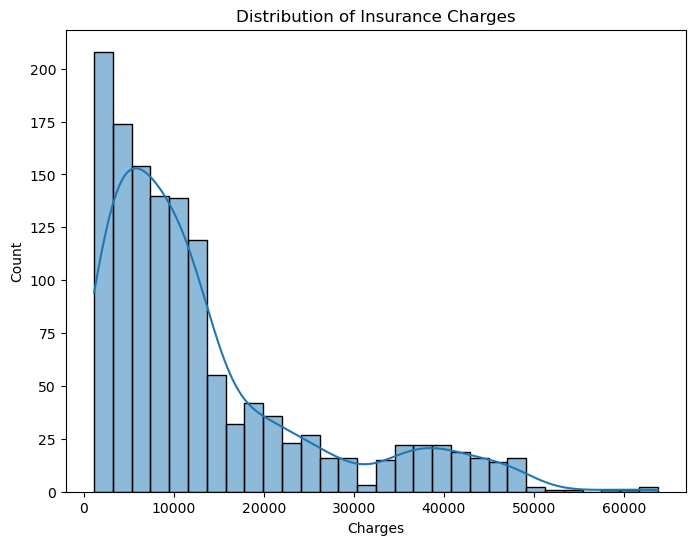

In [22]:
# Visualizing the distribution of the target variable 'charges'
plt.figure(figsize=(8,6))
sns.histplot(df1['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')

In [23]:
# data preprocessing
# Encoding categorical variables
df1.sex.replace({'male':1,'female':0}, inplace=True)
df1.smoker.replace({'yes':1,'no':0}, inplace=True)
df1.region.replace({'southeast':0,'southwest':1,'northeast':2,'northwest':3}, inplace=True)
df1.head()

# Splitting the dataset into features and target variable
X = df1.drop('charges', axis=1)
y = df1['charges']
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Training the Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
# Making predictions on the test set
y_pred = lr.predict(X_test)
print(y_pred)



# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print("Model evaluation completed.")




[ 8597.28489536  7231.74388195 37039.23208958  9616.21212862
 27161.15504663 11108.40935815   354.21613174 17042.35421504
   747.16617118 11372.94571472 28400.38875084  9533.99600035
  5216.48749305 38355.5614174  40201.25019476 37046.88317993
 15158.02888612 35867.31947109  9063.07424995 31650.09572393
  4122.46955807 10389.18037453  2647.70215941  6752.0935722
 11455.70143538 12576.55372408 14761.43409329  6317.33228079
  9588.04741124  2138.14714947  9375.87714427 13225.72806329
  4510.16138921  3585.45839256  4732.66994672 12637.34626748
  2260.33231947  9078.92932601 33459.16411947 32548.1168527
  4174.80105455  4490.15618578 14392.1262442  11588.95999023
  8712.67197642 12363.57345011  5437.31098673  3428.38801627
 35447.7739549   9084.07365487 15767.62103266  2302.7507234
 12500.96481021  1124.34689348 13327.47845234 12187.16682473
  3981.0147192  32336.2299135  13577.99152532 12510.93275623
 14425.49476583 10429.58572973 16603.90251205  7929.54465618
 11458.45482595  4232.50073

In [ ]:
# Observations for Linear Regression Model:
# 1. The distribution of insurance charges is right-skewed, indicating that most individuals have lower charges, while a few have significantly higher charges.
# 2. The actual vs predicted charges plot shows that while the model captures the general trend, there are some discrepancies, especially for higher charges, suggesting that the model may not be capturing all the complexities of the data.

# Conclusion for Linear Regression Model:
# The Linear Regression model provides a basic understanding of the relationship between the features and insurance charges.
# However, the performance metrics indicate that there is room for improvement. Future work could involve exploring more complex models, feature engineering, and hyperparameter tuning to enhance the predictive accuracy of the model.


# Best Practices and Future Work:
# 1. Feature Engineering: Creating new features or transforming existing ones (e.g., interaction terms, polynomial features) could help capture more complex relationships in the data.
# 2. Model Selection: Exploring other regression models such as Decision Trees, Random Forest to Linear Regression.
# 3. Hyperparameter Tuning: Using techniques like Grid Search or Random Search to find the best hyperparameters for the chosen model can enhance its performance.
# Overall, while the Linear Regression model provides a starting point, there are several avenues for improving the model's performance and better capturing the underlying patterns in the data.



In [24]:
#working on improving the model by using Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Training the Random Forest Regressor model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Making predictions on the test set
y_pred_rf = rf.predict(X_test)

# Evaluating the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest Mean Absolute Error: {mae_rf}')
print(f'Random Forest Mean Squared Error: {mse_rf}')
print(f'Random Forest R^2 Score: {r2_rf}')
print("Random Forest model evaluation completed.")

Random Forest Mean Absolute Error: 2520.5682441914237
Random Forest Mean Squared Error: 20919719.981469467
Random Forest R^2 Score: 0.8652503000800493
Random Forest model evaluation completed.


Text(0.5, 0, 'Charges')

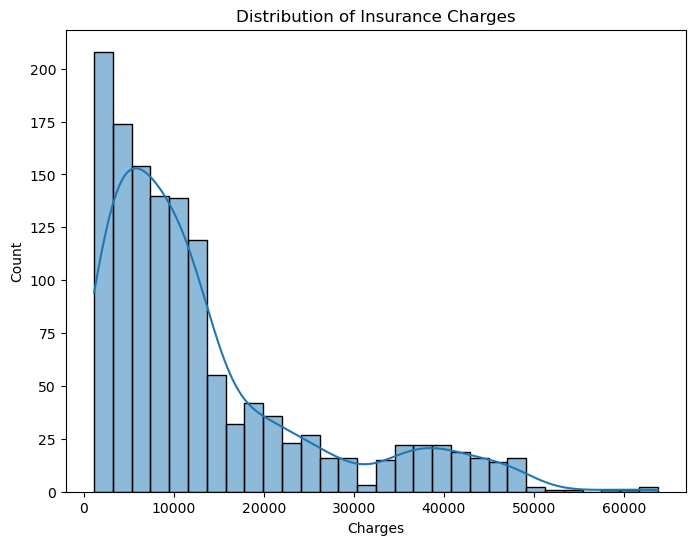

In [25]:
# Visualizing the distribution of the target variable 'charges'
plt.figure(figsize=(8,6))
sns.histplot(df1['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')


In [ ]:
# Observations for Random Forest Model:
# 1. The Random Forest model has a lower Mean Absolute Error and Mean Squared Error compared to the Linear Regression model, indicating that it has better predictive accuracy.
# 2. The R^2 Score for the Random Forest model is higher than that of the Linear Regression model,
# 3. suggesting that it explains a greater proportion of the variance in the target variable.

# Conclusion for Random Forest Model: Overall, the Random Forest model has shown improved performance compared to the Linear Regression model.



In [ ]:
#working on improving the model by using decision tree regressor

from sklearn.tree import DecisionTreeRegressor
# Training the Decision Tree Regressor model
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
# Making predictions on the test set
y_pred_dt = dt.predict(X_test)
# Evaluating the Decision Tree model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f'Decision Tree Mean Absolute Error: {mae_dt}')
print(f'Decision Tree Mean Squared Error: {mse_dt}')
print(f'Decision Tree R^2 Score: {r2_dt}')
print("Decision Tree model evaluation completed.")


Decision Tree Mean Absolute Error: 3449.168771768657
Decision Tree Mean Squared Error: 47754592.63855501
Decision Tree R^2 Score: 0.6923994664582139
Decision Tree model evaluation completed.


In [27]:
#comparing the performance of all three models
print("Model Performance Comparison:")
print(f'Linear Regression - MAE: {mae}, MSE: {mse}, R^2: {r2}')
print(f'Random Forest - MAE: {mae_rf}, MSE: {mse_rf}, R^2: {r2_rf}')
print(f'Decision Tree - MAE: {mae_dt}, MSE: {mse_dt}, R^2: {r2_dt}')


Model Performance Comparison:
Linear Regression - MAE: 4190.220190137915, MSE: 33685623.35414443, R^2: 0.783021587162344
Random Forest - MAE: 2520.5682441914237, MSE: 20919719.981469467, R^2: 0.8652503000800493
Decision Tree - MAE: 3449.168771768657, MSE: 47754592.63855501, R^2: 0.6923994664582139


In [ ]:
# Final Conclusion:
# Best model is random forest regressor as it has the lowest MAE and MSE and highest R^2 score among the three models.
# Making it the best choice for predicting insurance charges in this dataset.
# Overall, the Random Forest model has shown improved performance compared to both the Linear Regression and Decision Tree models.

